# Olist's Metric Design 

In this challenge, we are going to look into `Olist's business health`.

In [1]:
# Import Modules
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

**In this challenge, we'll reach back for some of our original data tables because we need some additional data. Don't use your `Order`, `Product` or `Seller` class for these ones.**

In [2]:
# Loading the data
from olist.data import Olist
data = Olist().get_data()

## Test your import!

In [3]:
from nbresult import ChallengeResult

result = ChallengeResult('orders',
    keys_len=len(data),
    key_names=sorted(list(data.keys())),
    reviews_number=len(data['order_reviews'])
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/bin/python
cachedir: .pytest_cache
rootdir: /Users/davywai/code/lewagon/wgn-ds-2025/Module03_DecisionScience/W02D05__LogisticRegression/solution_03-Decision-Science_03-Logistic-Regression_03-Metric-Design/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_orders.py::TestOrders::test_key_names PASSED                        [ 33%]
test_orders.py::TestOrders::test_keys_len PASSED                         [ 66%]
test_orders.py::TestOrders::test_reviews_number PASSED                   [100%]

============================== 3 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/orders.pickle

git commit -m 'Completed orders step'

git push origin master



Before you get started, make sure to check the ERD of Olist's data again:

<img src="https://wagon-public-datasets.s3.amazonaws.com/04-Decision-Science/01-Project-Setup/olist_schema_v2.png" width=1000>

## 1 - Orders vs. Reviews?

❓Plot a chart counting the number of order reviews for each `review_score`. Use seaborn's `countplot()`.

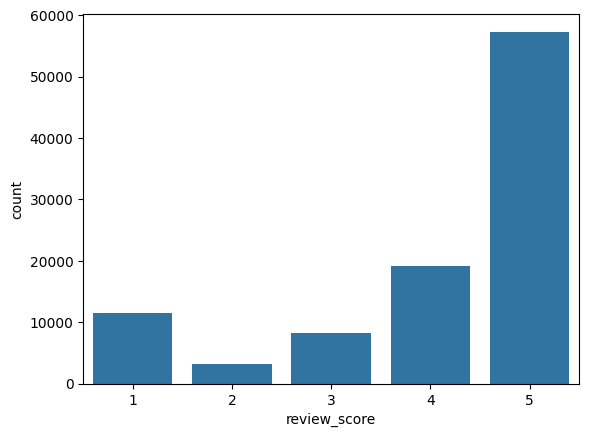

In [4]:
sns.countplot(x='review_score', data=data['order_reviews']);

❓ Plot a chart counting the number of orders by `order_status` <br/>

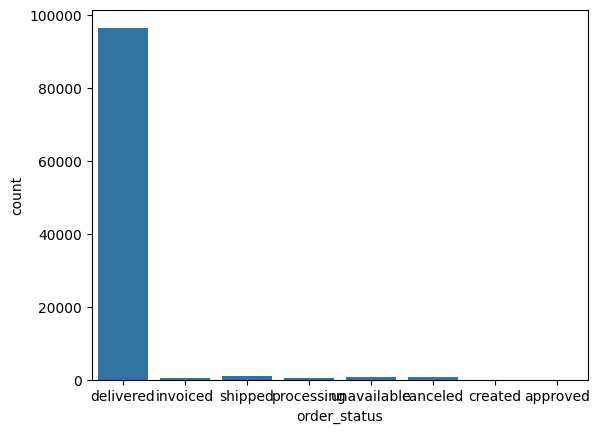

In [5]:
sns.countplot(data=data['orders'], x='order_status');

❓ How many of them are delivered ? shipped ? canceled ? ...

In [6]:
data['orders']['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

💡 We already know - from our data schema - that each `review` has a unique `order`.

🤔 Do all `orders` have a `review`?

<details>
    <summary><i>▸ Hint</i></summary>

You can use `pd.Series.isna().sum()` to count the number of NaN values in a series
</details>

In [7]:
orders_reviews = data['orders'].merge(data['order_reviews'], on='order_id', how='left')
orders_reviews[['order_id', 'review_score']].isna().sum()

order_id          0
review_score    768
dtype: int64

If some orders were not reviewed, count and group them per `order_status`.

In [8]:
orders_reviews.groupby(['order_status'])['review_score'].apply(lambda s: s.isna().sum()).sort_values(ascending = False)

order_status
delivered      646
shipped         75
canceled        20
unavailable     14
processing       6
invoiced         5
created          2
approved         0
Name: review_score, dtype: int64

## 2 - Evolution of key business metrics over the past 14 months

## Metrics 

1. Which metric would you use as a `key business output metric`for Olist  📈 ? 
2.  Which metric would you use to measure that a customer had a `good experience with Olist` 🙂 ? 
3. Which metric would you use to measure `shipping delay` 🕗?

For each metric, plot a trend line over time. You can use Pandas' built-in `.plot()` method.

### Metric 1: Order numbers

❓ Plot the weekly number of total orders per week (to check how business is going).



<details>
    <summary><i>Hint </i></summary>

  - Which date will you use?
  - Convert dates to Python `datetime` objects.
  - Use Pandas' [resample method](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html).

</details>

In [9]:
# Orders dataset
orders = data['orders'].copy()
# Handle datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders = orders.set_index('order_purchase_timestamp').sort_index()

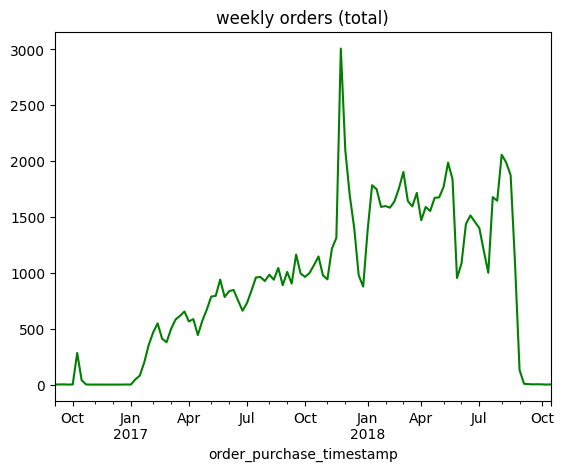

In [10]:
orders.resample('W')['order_id'].count().plot(color='g')
plt.title('weekly orders (total)');

❓ Visualize the weekly number of non-delivered orders (to check for any potential issues)

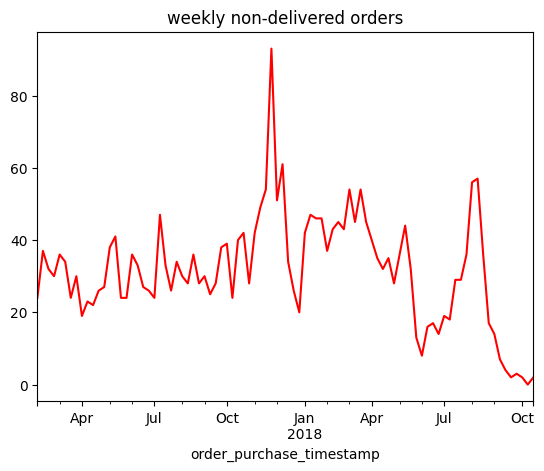

In [11]:
orders.sort_index().query("order_status != 'delivered'").loc['2017-02-01':].resample('W')['order_id'].count().plot(color='r')
plt.title('weekly non-delivered orders');

### Metric 1-bis (optional): Total payment values
❓ After plotting the total number of orders, we could also have a look at the weekly sum of `payment_value` in `BRL` to approximate Olist's weekly revenues.

In [12]:
data['order_payments'].head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [13]:
order_ids_payments = data['order_payments'].groupby('order_id').sum()[['payment_value']]
order_ids_payments.rename(columns={'payment_value': 'order_payment_value'}, inplace=True)
order_ids_payments.head()

,order_payment_value
order_id,
00010242fe8c5a6d1ba2dd792cb16214,72.19
00018f77f2f0320c557190d7a144bdd3,259.83
000229ec398224ef6ca0657da4fc703e,216.87
00024acbcdf0a6daa1e931b038114c75,25.78
00042b26cf59d7ce69dfabb4e55b4fd9,218.04


💡 Merge the `payments` dataset with the `orders` dataset to collect the date of each payment.

In [14]:
orders_payments = data['orders'].merge(order_ids_payments, on='order_id')

⌛️ Once again, do not forget to handle datetimes properly

In [15]:
# handle datetime
for col in ['order_purchase_timestamp', 'order_approved_at', \
            'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    orders_payments[col] = pd.to_datetime(orders_payments[col])
orders_payments.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62


📈 Visualize the number of orders and total amount of payments per week

<details>
    <summary><i>Hint </i></summary>

- Call the `.plot()` for the number of orders and paymount amounts in the same cell to visualize them together in one plot.
- You might want to show the total payment amount in thousands of BRL to make it easier to visualize.
- You can add labels to distinguish the three plots by setting a `label` in the `.plot()` and by calling `plt.legend()` at the end of your cell.

</details>

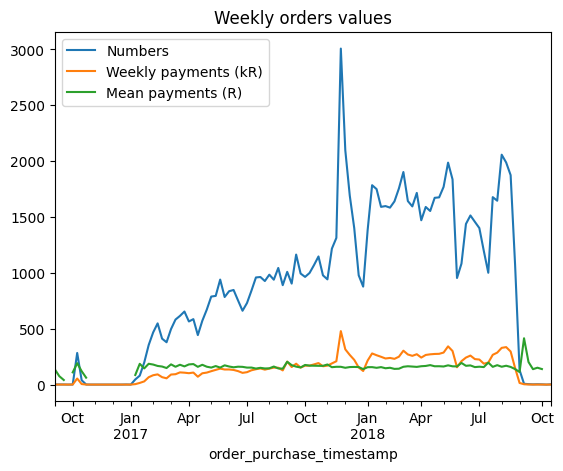

In [16]:
weekly_orders_payments = orders_payments.set_index('order_purchase_timestamp').resample('W')
weekly_orders_payments['order_id'].count().plot(label='Numbers')
weekly_orders_payments['order_payment_value'].sum().apply(lambda x: x/1000).plot(label='Weekly payments (kR)')
weekly_orders_payments['order_payment_value'].mean().plot(label='Mean payments (R)')
plt.legend()
plt.title('Weekly orders values');

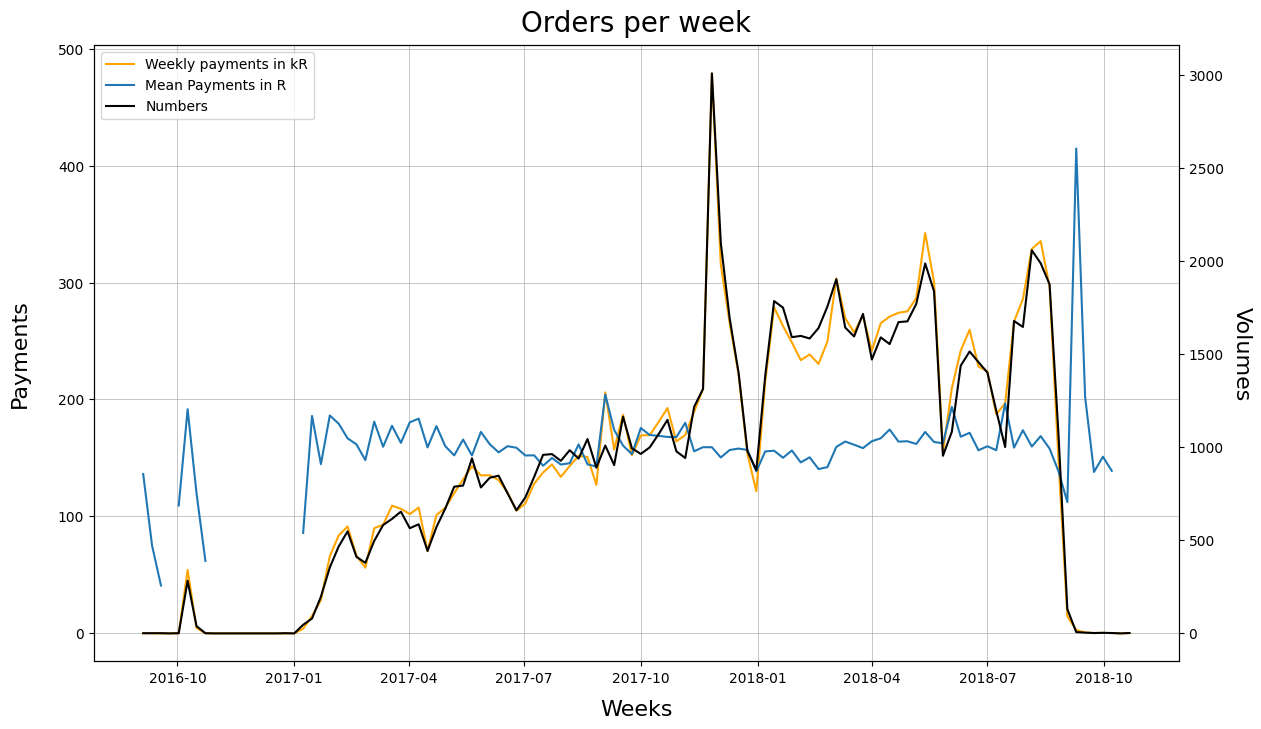

In [17]:
# Plot numbers of weekly orders purchased
# (optional) Plot like a pro !
# Just to show how hard this is to do with matplotlib

with plt.style.context('fast'):
    # figsize
    plt.figure(figsize=(14, 8))
    # getting axes
    ax1 = plt.gca()
    # duplicating the ax1
    ax2 = ax1.twinx()
    # Weekly payments and Mean Payments

    ax1.plot(weekly_orders_payments['order_payment_value'].sum().apply(lambda x: x/1000),
             color="orange",
             label="Weekly payments in kR")
    ax1.plot(weekly_orders_payments['order_payment_value'].mean(),
             label="Mean Payments in R")
    ax1.set_xlabel("Weeks",
                   fontsize=16,
                   labelpad=10)
    ax1.set_ylabel("Payments",
                   fontsize=16,
                   labelpad=20)

    # Numbers
    ax2.plot(weekly_orders_payments['order_id'].count(),
             label="Numbers",
             c="black")
    ax2.set_ylabel("Volumes",
                   fontsize=16,
                   rotation=90*3,
                   labelpad=20)

    # Get a common legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    # Title
    ax1.set_title('Orders per week',
                  fontsize=20,
                  pad=10)

    # Grid
    ax1.grid(axis="x", linewidth=0.5)
    ax1.grid(axis="y", linewidth=0.5)
    plt.show()

### Metric 2: Customer Satisfaction
❓ How does the `customer satisfaction` evolve on a monthly basis ? Use the mean average `review_score` to illustrate the customer satisfaction.

👉 Load the `reviews` :

In [18]:
reviews = data['order_reviews'].copy()

In [19]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


⌛️ If you need to handle datetime, do it.

In [20]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews.set_index('review_creation_date', inplace=True)

📉 Plot the customer satisfaction evolution over time

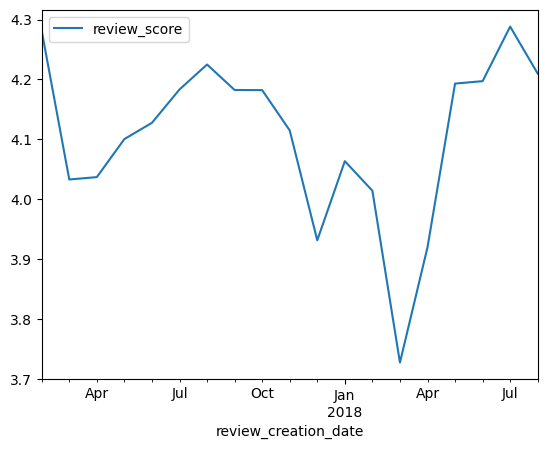

In [21]:
reviews.loc['2017-02-01':].resample('ME').agg({'review_score':'mean'}).plot();

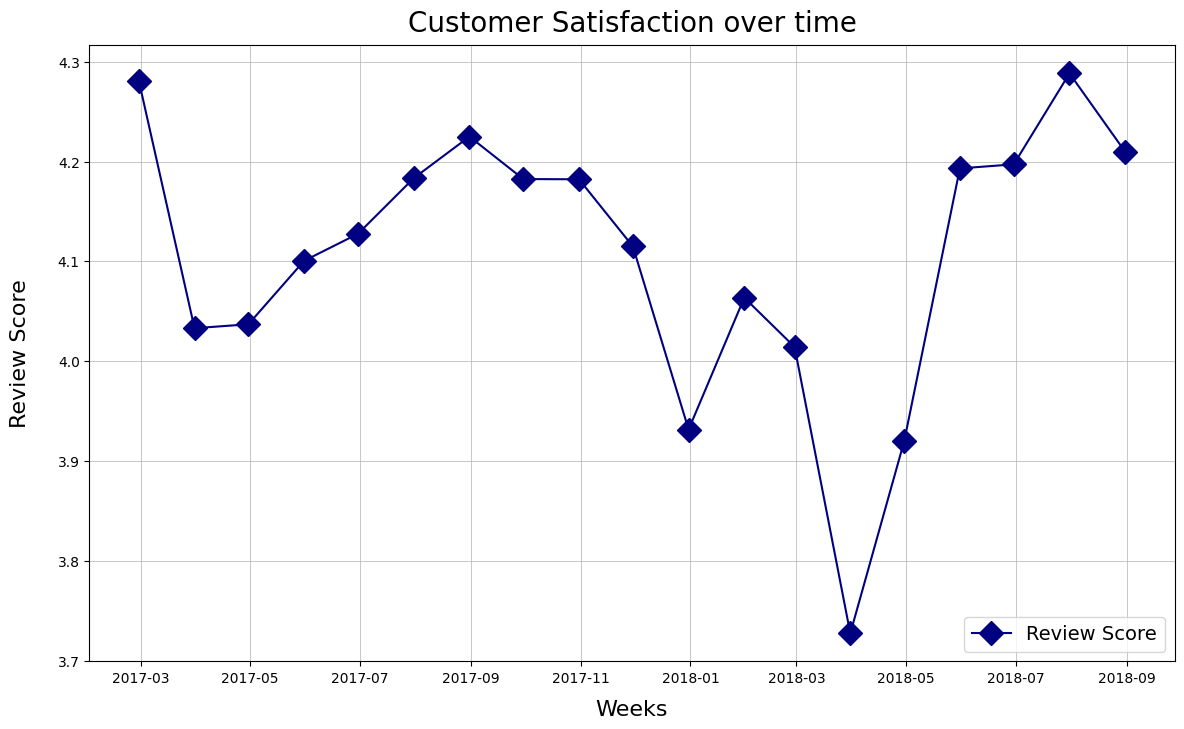

In [22]:
# Customer satisfaction over time
# (optional) Plot like a pro !

with plt.style.context('fast'):
    # figsize
    plt.figure(figsize=(14, 8))
    # getting axes
    ax = plt.gca()
    # Customer Satisfaction over time

    ax.plot(reviews.loc['2017-02-01':].resample('ME').agg({'review_score': 'mean'}),
            color="#000080",
            marker="D",
            markersize=12,
            label="Review Score")
    ax.set_xlabel("Weeks", fontsize=16, labelpad=10)
    ax.set_ylabel("Review Score", fontsize=16, labelpad=20)

    # Get a  legend
    ax.legend(loc='lower right', fontsize=14)

    # Title
    ax.set_title('Customer Satisfaction over time', fontsize=20, pad=10)

    # Grid
    ax.grid(axis="x", linewidth=0.5)
    ax.grid(axis="y", linewidth=0.5)
    plt.show()

### Metric 3: Shipping delay

❓Create two new metrics, `delay_vs_expected` and `wait_time` in ***days***, from the `orders` dataset, and plot their historical evolution on a weekly basis to detect trends

Wait a minute, `delay_vs_expected` and `wait_time`, didn't we calculate that before?

Yes, in `olist.order`. The thing is: we don't have the order purchase date in that dataset, which we made for **modelling**. Here we are looking at time series: an evolution over time, so we need that date. This is why reach back to the original data.

Alternatively, we could merge:
- `Order().get_training_data()` (with the the `wait_time` and `delay_vs_expected` features) and
- `data['orders']` (the original data, with the datetime information).

But a merge operation is computationally expensive, so let's just start from the original data instead, and re-calculate the `wait_time` and `delay_vs_expected`.

🛒 Let's focus on delivered orders so that we can compute the shipping delays:

In [23]:
orders = orders.query("order_status=='delivered'").reset_index()

⌛️ Datetime problems again ? Fix them ;)

In [24]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

👉 Compute the delay between the actual delivery date and the ETA for each order.

In [25]:
orders['delay_vs_expected'] = (orders['order_delivered_customer_date'] \
                             - orders['order_estimated_delivery_date']) \
                             / np.timedelta64(24, 'h')

👉 Compute the waiting time between the actual delivery date and the moment a customer ordered their items

In [26]:
orders['wait_time'] = (orders['order_delivered_customer_date'] \
                     - orders['order_purchase_timestamp']) \
                     / np.timedelta64(24, 'h')

⌛️ How many orders were delivered later than expected ? <br/>
*You can also give an answer in terms of percentage if you prefer.*
<details>
    <summary><i>▸ Hint </i></summary>

    
You can create a `boolean_feature` which is :
* True when actual_delivered_date > ETA $\leftrightarrow$ actual_delivered_date - ETA > 0
* False otherwise
    
</details>




In [27]:
# create a boolean feature that says whether an order was delivered with a delay or not
# delay_vs_expected > 0
# <=> actual_delivered date > ETA
# <=> actual_delivered date - ETA > 0

orders["was_late"] = orders['delay_vs_expected'].map(lambda x: x > 0)

# early_or_in_time is just a nice column but it's redundant with the was_late
orders["early_or_on_time"] = orders["was_late"].map({True:"late", False:"in_time"})

In [28]:
orders["early_or_on_time"].value_counts()

early_or_on_time
in_time    88652
late        7826
Name: count, dtype: int64

In [29]:
round(orders["early_or_on_time"].value_counts(normalize=True), 2)

early_or_on_time
in_time    0.92
late       0.08
Name: proportion, dtype: float64

* On average, 8% of the orders are delivered after the ETA ⌛️

* Let's find which weeks were the worst 👇
    1. Aggregate the dataset per week
    2. Compute the percentage of orders delivered lately each week

In [30]:
orders

,order_purchase_timestamp,order_id,customer_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delay_vs_expected,wait_time,was_late,early_or_on_time
0,2016-09-15 12:16:38,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,36.324745,54.813194,True,late
1,2016-10-03 09:44:50,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,-0.415127,23.178738,False,in_time
2,2016-10-03 16:56:50,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,-10.236366,24.057500,False,in_time
3,2016-10-03 21:13:36,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,-25.542975,30.572581,False,in_time
4,2016-10-03 22:06:03,d207cc272675637bfed0062edffd0818,b8cf418e97ae795672d326288dfab7a7,delivered,2016-10-04 10:28:07,2016-10-21 14:23:37,2016-10-31 11:07:42,2016-11-23,-22.536319,27.542813,False,in_time
...,...,...,...,...,...,...,...,...,...,...,...,...
96473,2018-08-29 12:25:59,52018484704db3661b98ce838612b507,e450a297a7bc6839ceb0cf1a2377fa02,delivered,2018-08-29 12:35:17,2018-08-29 13:38:00,2018-08-30 22:48:27,2018-09-03,-3.049688,1.432269,False,in_time
96474,2018-08-29 14:18:23,0b223d92c27432930dfe407c6aea3041,e60df9449653a95af4549bbfcb18a6eb,delivered,2018-08-29 14:31:07,2018-08-29 15:29:00,2018-08-30 16:24:55,2018-09-04,-4.316030,1.087870,False,in_time
96475,2018-08-29 14:18:28,168626408cb32af0ffaf76711caae1dc,6e353700bc7bcdf6ebc15d6de16d7002,delivered,2018-08-29 14:30:23,2018-08-29 18:51:00,2018-08-30 16:52:31,2018-09-11,-11.296863,1.106979,False,in_time
96476,2018-08-29 14:52:00,03ef5dedbe7492bdae72eec50764c43f,496630b6740bcca28fce9ba50d8a26ef,delivered,2018-08-29 15:05:22,2018-08-29 20:01:00,2018-08-30 16:36:59,2018-09-03,-3.307650,1.072905,False,in_time


In [31]:
delay_analysis_per_week = orders.set_index('order_purchase_timestamp').resample('W').agg({
    'delay_vs_expected': 'mean',
    'wait_time': 'mean',
    'was_late': 'sum',
    'order_id': 'count'
    })

delay_analysis_per_week.columns = ['avg_delay_vs_exp', 'avg_wait_time',
                                   'nb_of_delays', 'nb_of_orders']

delay_analysis_per_week['pct_of_lateness'] = delay_analysis_per_week['nb_of_delays'] \
                                           / delay_analysis_per_week['nb_of_orders']

print("-"*40)
print("Delay Analysis per week")
print("-"*40)
display(round(delay_analysis_per_week.tail(10), 2))

----------------------------------------
Delay Analysis per week
----------------------------------------


,avg_delay_vs_exp,avg_wait_time,nb_of_delays,nb_of_orders,pct_of_lateness
order_purchase_timestamp,,,,,
2018-07-01,-16.78,8.33,10,1382,0.01
2018-07-08,-13.84,8.52,19,1178,0.02
2018-07-15,-9.88,11.27,59,972,0.06
2018-07-22,-10.40,9.03,65,1649,0.04
2018-07-29,-9.92,8.32,63,1610,0.04
2018-08-05,-6.57,8.66,276,2002,0.14
2018-08-12,-7.01,8.49,243,1931,0.13
2018-08-19,-8.52,7.63,133,1839,0.07
2018-08-26,-8.32,5.48,71,1054,0.07


📈 Plot the `number of delays` and `percentage of delayed orders` per week

<details>
    <summary><i>Hint </i></summary>

- Call the `.plot()` for the number of orders and percentage delayed in the same cell to visualize them together in one plot.
- A percentage obviously gets squeezed into a flat line when plotted together with the number of orders. The `.plot()` method has an option to plot against the right axis. Check the docs.
- You can add labels to distinguish the three plots by setting a `label` in the `.plot()` and by calling `plt.legend()` at the end of your cell.

</details>

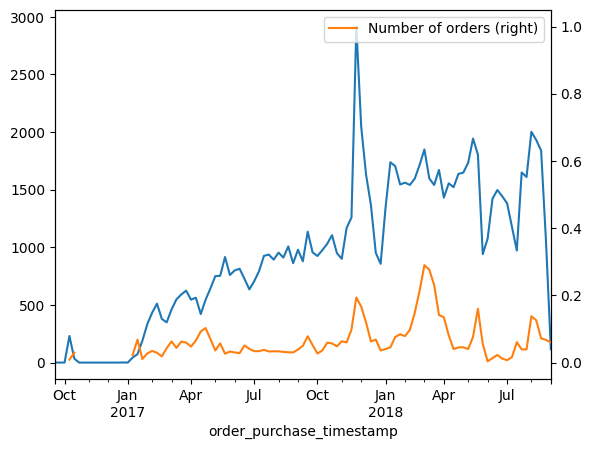

In [ ]:
delay_analysis_per_week['nb_of_orders'].plot(label='Number of orders')
delay_analysis_per_week['pct_of_lateness'].plot(label='Number of orders', secondary_y=True)
plt.legend()

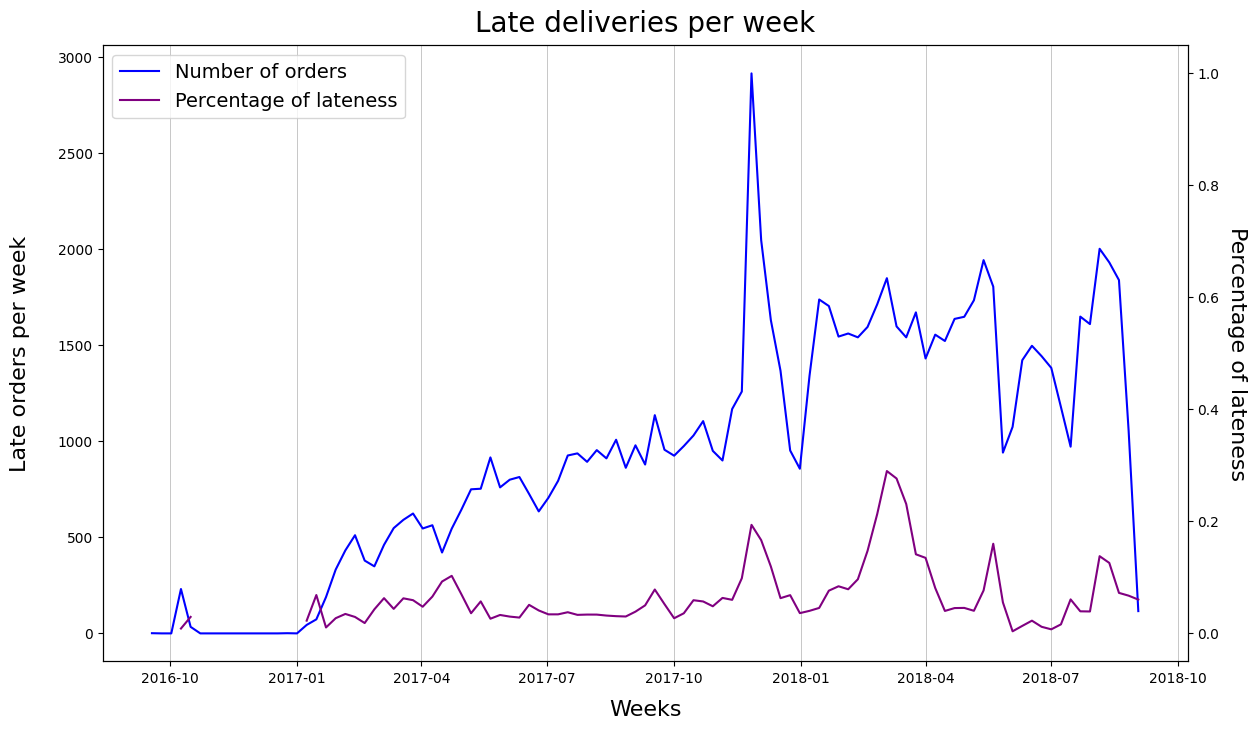

In [32]:
# Or with pure matplotlib, don't do this
with plt.style.context('fast'):
    # figsize
    plt.figure(figsize=(14, 8))
    # getting axes
    ax1 = plt.gca()
    # duplicating the ax1
    ax2 = ax1.twinx()
    # Weekly payments and Mean Payments

    ax1.plot(delay_analysis_per_week['nb_of_orders'],
             color="blue",
             label="Number of orders")
    ax1.set_xlabel("Weeks",
                   fontsize=16,
                   labelpad=10)
    ax1.set_ylabel("Late orders per week",
                   fontsize=16,
                   labelpad=20)

    # Numbers
    ax2.plot(delay_analysis_per_week['pct_of_lateness'],
             label="Percentage of lateness",
             c="purple")
    ax2.set_ylabel("Percentage of lateness",
                   fontsize=16,
                   rotation=90*3,
                   labelpad=20)

    # Get a conjoined legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize = 14)

    # Title
    ax1.set_title('Late deliveries per week',
                  fontsize=20,
                  pad=10)

    # Vertical lines
    #ax1.xvlines(x="2018-03-04")

    # Grid
    ax1.grid(axis="x", linewidth=0.5)
    plt.show()

#### Delay Analysis

📈 📉 From the previous graph, Olist experienced major lateness issues on 3-4 weeks ⚠️...

👉 Let's deep dive into these peaks of lateness.

❓ Create a dataframe (with weeks as indexes ) with the following columns:
* number of delays
* number of orders
* percentage of delayed orders

In [33]:
round(delay_analysis_per_week[['nb_of_delays', 'nb_of_orders', 'pct_of_lateness']].sort_values(by='pct_of_lateness', ascending=False).head(10), 2)

,nb_of_delays,nb_of_orders,pct_of_lateness
order_purchase_timestamp,,,
2016-09-18,1,1,1.00
2018-03-04,536,1849,0.29
2018-03-11,442,1598,0.28
2018-03-18,356,1541,0.23
2018-02-25,365,1713,0.21
2017-11-26,565,2915,0.19
2017-12-03,341,2047,0.17
2018-05-20,289,1805,0.16
2018-02-18,235,1595,0.15


❓ Create sub-dataframes to seperate these weeks into subgroups.

A suggestion:
- 20% and more
- 15-20%
- 10-15%
- 5-10%
- 5% and less

In [34]:
lateness_20_and_more = delay_analysis_per_week.query("pct_of_lateness >= 0.20")
display(round(lateness_20_and_more[1:][['nb_of_delays', 'nb_of_orders', 'pct_of_lateness']], 2))

,nb_of_delays,nb_of_orders,pct_of_lateness
order_purchase_timestamp,,,
2018-02-25,365,1713,0.21
2018-03-04,536,1849,0.29
2018-03-11,442,1598,0.28
2018-03-18,356,1541,0.23


In [35]:
lateness_15_20 = delay_analysis_per_week[delay_analysis_per_week["pct_of_lateness"].between(0.15, 0.20)]
display(round(lateness_15_20[['nb_of_delays', 'nb_of_orders', 'pct_of_lateness']], 2))

,nb_of_delays,nb_of_orders,pct_of_lateness
order_purchase_timestamp,,,
2017-11-26,565,2915,0.19
2017-12-03,341,2047,0.17
2018-05-20,289,1805,0.16


In [36]:
lateness_10_15 = delay_analysis_per_week[delay_analysis_per_week["pct_of_lateness"].between(0.10, 0.15)]
display(round(lateness_10_15[['nb_of_delays', 'nb_of_orders', 'pct_of_lateness']], 2))

,nb_of_delays,nb_of_orders,pct_of_lateness
order_purchase_timestamp,,,
2017-04-23,56,545,0.10
2017-12-10,195,1631,0.12
2018-02-18,235,1595,0.15
2018-03-25,236,1671,0.14
2018-04-01,193,1431,0.13
2018-08-05,276,2002,0.14
2018-08-12,243,1931,0.13


In [37]:
lateness_05_10 = delay_analysis_per_week[delay_analysis_per_week["pct_of_lateness"].between(0.05, 0.10)]

In [38]:
lateness_05_and_less = delay_analysis_per_week[delay_analysis_per_week["pct_of_lateness"].between(0.00, 0.05)]

In [39]:
lateness_brackets = pd.Series([
    " ≥ 20%",
    "15% - 20%",
    "10% - 15%",
    "5% - 10%",
    " ≤ 5%"
])

lateness_numbers = pd.Series([
    lateness_20_and_more.shape[0]-1,
    lateness_15_20.shape[0],
    lateness_10_15.shape[0],
    lateness_05_10.shape[0],
    lateness_05_and_less.shape[0]

])

lateness_df = pd.concat([lateness_brackets, lateness_numbers], axis = 1)
lateness_df.columns = ['brackets', 'nb_weeks']

display(lateness_df)

,brackets,nb_weeks
0,≥ 20%,4
1,15% - 20%,3
2,10% - 15%,7
3,5% - 10%,30
4,≤ 5%,46


In [40]:
np.sum(lateness_df['nb_weeks'])

90

⚠️⚠️⚠️ Among these 90 weeks, Olist encountered serious troubles⚠️⚠️⚠️
* there are 4 weeks for which more than 20% of the orders were delivered way later than expected
* there are 3 weeks for which more 15-20% of the orders were delivered way later than expected
* there are 7 weeks for which more 10-15% of the orders were delivered way later than expected

👀 Hints/questions you can investigate to go further in the analysis :
- Check the Brazilian calendar 🇧🇷 🗓
- Were some specific sellers and/or products involved during these weeks ?